In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import StandardScaler

x1,_ = make_blobs(n_samples=1000, n_features=2, centers=[[0,0]], cluster_std=.15, random_state=42)
x2,_ = make_blobs(n_samples=1000, n_features=2, centers=[[5,5]], cluster_std=.85, random_state=42)

x = np.vstack((x1,x2))
x_scaled = StandardScaler().fit_transform(x)

c:\Users\Ayush\miniconda3\envs\Purva_Patole\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


--- HDBSCAN Production Performance ---
Unique Clusters Extracted (Despite Variable Density): 2
Noise Outliers Isolated (-1 Labels)                  : 0


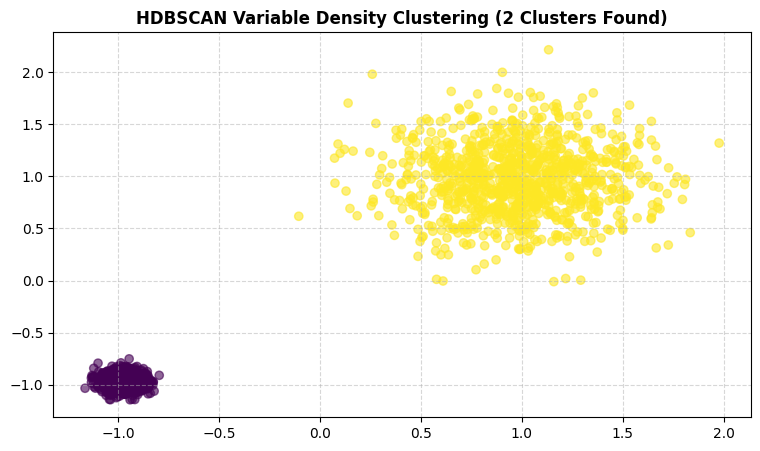

In [5]:
hdb = HDBSCAN(min_cluster_size=25, min_samples=5,store_centers='centroid')
cluster_labels = hdb.fit_predict(x_scaled)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)

print("--- HDBSCAN Production Performance ---")
print(f"Unique Clusters Extracted (Despite Variable Density): {n_clusters}")
print(f"Noise Outliers Isolated (-1 Labels)                  : {n_noise}")

plt.figure(figsize=(9, 5))
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
plt.title(f"HDBSCAN Variable Density Clustering ({n_clusters} Clusters Found)", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()